In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import keras
import tensorflow.python.keras as utils
import os
import imageio
%matplotlib inline
from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
from keras.layers import Dense, Flatten, InputLayer
from PIL import Image

In [3]:
train = pd.read_csv(r'C:\unknown\train.csv')
test = pd.read_csv(r'C:\unknown\test.csv')

6825
age_grp: MIDDLE


C:\Users\dwijt\AppData\Local\Temp\ipykernel_22040\2342212405.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(os.path.join(r'C:\\unknown\\Train', img_name))


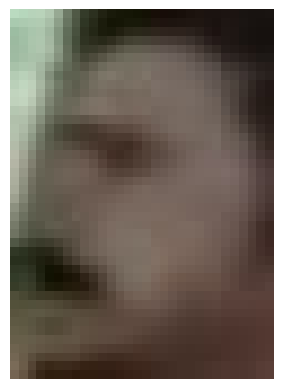

In [4]:
np.random.seed(16)
a = np.random.choice(train.index)
print(a)
img_name = train.ID[a]
img = imageio.imread(os.path.join(r'C:\\unknown\\Train', img_name))

print('age_grp:', train.Class[a])
plt.imshow(img)
plt.axis('off')
plt.show()

In [5]:
temp = []

for img_name in train.ID:
    img_path = os.path.join(r'C:\\unknown\\Train', img_name)
    img = imageio.imread(img_path)
    img = np.array(Image.fromarray(img).resize((32,32))).astype('float32')
    temp.append(img)
    
train_x = np.stack(temp)

C:\Users\dwijt\AppData\Local\Temp\ipykernel_22040\2449476201.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(img_path)


In [6]:
temp = []

for img_name in test.ID:
    img_path = os.path.join(r'C:\\unknown\\Test', img_name)
    img = imageio.imread(img_path)
    img = np.array(Image.fromarray(img).resize((32,32))).astype('float32')
    temp.append(img)
    
test_x = np.stack(temp)

C:\Users\dwijt\AppData\Local\Temp\ipykernel_22040\3141993399.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(img_path)


In [7]:
train_x = train_x/200
test_x = test_x/200

In [8]:
train.Class.value_counts(normalize = True)

Class
MIDDLE    0.542751
YOUNG     0.336883
OLD       0.120366
Name: proportion, dtype: float64

In [9]:
le = LabelEncoder()

train_y = le.fit_transform(train.Class)
train_y = keras.utils.to_categorical(
    train_y,
    num_classes = len(le.classes_)
)

In [30]:
input_num_units = (32, 32, 3)
hidden_num_units = 1000
output_num_units = 3

epochs = 10
batch_size = 100

model = Sequential([
    InputLayer(input_shape = input_num_units),
    Flatten(),
    Dense(hidden_num_units, activation = 'relu'),
    Dense(output_num_units, activation = 'softmax')
])

In [31]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1000)           │     3,073,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │         3,003 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,076,003 (11.73 MB)

 Trainable params: 3,076,003 (11.73 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model.compile(optimizer = 'sgd', loss = 'categorical_crossentropy', metrics = [('accuracy')])
model.fit(train_x, train_y, batch_size = batch_size, epochs= epochs,verbose= 1)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7506 - loss: 0.5931
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7557 - loss: 0.5894
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7514 - loss: 0.5888
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7551 - loss: 0.5852
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7515 - loss: 0.5902
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7581 - loss: 0.5781
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7640 - loss: 0.5727
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7597 - loss: 0.5778
Epoch 9/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7591 - loss: 0.5734
Epoch 10/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7644 - loss: 0.5675


In [41]:
model.fit(train_x, train_y, batch_size = batch_size, epochs= epochs,verbose= 1, validation_split = 0.1)

Epoch 1/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7893 - loss: 0.5213 - val_accuracy: 0.7659 - val_loss: 0.5497
Epoch 2/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7926 - loss: 0.5138 - val_accuracy: 0.7539 - val_loss: 0.5765
Epoch 3/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7871 - loss: 0.5182 - val_accuracy: 0.6826 - val_loss: 0.8168
Epoch 4/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7941 - loss: 0.5110 - val_accuracy: 0.6801 - val_loss: 0.7200
Epoch 5/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7910 - loss: 0.5108 - val_accuracy: 0.7494 - val_loss: 0.5916
Epoch 6/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7961 - loss: 0.5060 - val_accuracy: 0.7273 - val_loss: 0.6473
Epoch 7/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7934 - loss: 0.5080 - val_accuracy: 0.7097 - val_loss: 0.6540
Epoch 8/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7953 - loss: 0.5031 - val_accuracy: 0.

In [42]:
pred_prob = model.predict(test_x, verbose = 0)
pred = np.argmax(pred_prob, axis = 1)
pred = le.inverse_transform(pred)

test['Class'] = pred
test.to_csv('output.csv', index = False)


C:\Users\dwijt\AppData\Local\Temp\ipykernel_22040\915205121.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(os.path.join(r'C:\unknown\Test', img_name))


IndexError: index 220 is out of bounds for axis 0 with size 3

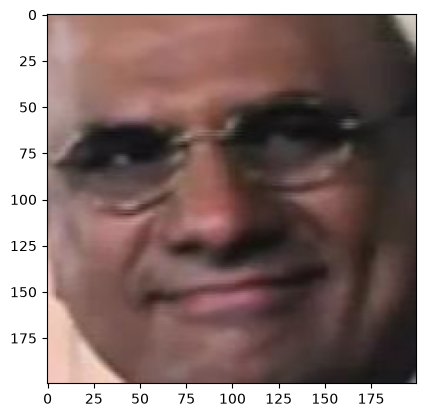

In [ ]:
idx = 220
img_name = test.ID[idx]

img = imageio.imread(os.path.join(r'C:\unknown\Test', img_name))
plt.imshow(np.array(Image.fromarray(img).resize((200, 200))))
pred_prob = model.predict(test_x, verbose = 0)
pred_indices =np.argmax(pred_prob, axis = 0)

pred_indices = np.argmax(pred_prob, axis=1)

print(
    'original = ', test.Class.iloc[idx],
    'predi = ', le.inverse_transform([pred_indices[idx]])[0]
)
print('Original = ', test.Class.iloc[idx], 'predi = ', pred[idx])
